<a href="https://colab.research.google.com/github/dougcarrico/mvp-qualidade-software/blob/main/Collab_Modelo_MVP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [126]:
# configuração para não exibir os warnings
import warnings
warnings.filterwarnings("ignore")

# Imports necessários
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression

from pickle import dump
from pickle import load

# Escolha do dataset

Decidi que iria trabalhar com dados relacionados à área da saúde. Fiz a escolha deste dataset baseado nas avaliações, documentação, organização e informação sobre os dados.

Estudando os dados encontrados no dataset, decidi criar um modelo de classificação que servirá de base para uma aplicação que classificará se o paciente tem ou não alguma doença cardiaca de acordo com os dados fornecidos;

Link de origem: https://www.kaggle.com/datasets/fedesoriano/heart-failure-prediction/data



In [127]:
# Lendo o Dataset via URL
url = "https://raw.githubusercontent.com/dougcarrico/estudo-datasets/refs/heads/main/heart.csv"

dataset = pd.read_csv(url, delimiter=',')

# Preview dos dados para conferir colunas
dataset.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


## Pré-processamento - Transformação de dados

Durante a análise dos dados percebi que precisaria fazer um processo de transformação nos dados para que os algoritmos pudessem trabalhar com os dados.
Primeiro decidi remover a coluna "Cholesterol", percebi que esta feature continha muitas linhas com valores iguais a 0, que são fora dos valores possíveis na realidade, indicando que poderiam ser valores nulos que foram transformados em 0. Tomei a decisão de remover a coluna para este estudo de caso.

In [128]:
# Remoção da coluna "Cholesterol" por ter uma grande quantidade de dados inconsistentes '0'.
dataset = dataset.drop(columns=['Cholesterol'])

dataset

,Age,Sex,ChestPainType,RestingBP,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,0,LVH,174,N,0.0,Flat,1


Fiz uma verificação nos valores únicos de cada coluna com dados categórigos para fazer um mapeamento.

In [129]:
# Exibe valores únicos presentes nas colunas especificadas
categorical_columns = ['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']
for col in categorical_columns:
    print(f"{col}: {dataset[col].unique()}")

Sex: ['M' 'F']
ChestPainType: ['ATA' 'NAP' 'ASY' 'TA']
RestingECG: ['Normal' 'ST' 'LVH']
ExerciseAngina: ['N' 'Y']
ST_Slope: ['Up' 'Flat' 'Down']


Após a conferência dos valores das colunas, fiz um mapeamento dos valores e criei um novo dataset com os dados mapeados.

In [130]:
# Mapeamento dos valores de string para numero em cada coluna categórica
mapped_dataset = dataset.copy()
mapped_dataset['Sex'] = mapped_dataset['Sex'].replace({'M': 0, 'F':1})
mapped_dataset['ChestPainType'] = mapped_dataset['ChestPainType'].replace({'ATA': 0, 'NAP':1, 'ASY':2, 'TA':3})
mapped_dataset['RestingECG'] = mapped_dataset['RestingECG'].replace({'Normal': 0, 'ST':1, 'LVH':2})
mapped_dataset['ExerciseAngina'] = mapped_dataset['ExerciseAngina'].replace({'N': 0, 'Y':1})
mapped_dataset['ST_Slope'] = mapped_dataset['ST_Slope'].replace({'Up': 0, 'Flat':1, 'Down':2})

# Exibe valores únicos presentes nas colunas especificadas para conferir mapeamento
for col in categorical_columns:
    print(f"{col}: {mapped_dataset[col].unique()}")

# Preview dos dados para conferir alguns valores e colunas
mapped_dataset.head()

Sex: [0 1]
ChestPainType: [0 1 2 3]
RestingECG: [0 1 2]
ExerciseAngina: [0 1]
ST_Slope: [0 1 2]


,Age,Sex,ChestPainType,RestingBP,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,0,0,140,0,0,172,0,0.0,0,0
1,49,1,1,160,0,0,156,0,1.0,1,1
2,37,0,0,130,0,1,98,0,0.0,0,0
3,48,1,2,138,0,0,108,1,1.5,1,1
4,54,0,1,150,0,0,122,0,0.0,0,0


## Pré-processamento - Separação de features e targets
Separação dos dados do dataframe para array X e y, formato que os algoritmos recebem os dados para treino e teste.

In [146]:
test_size = 0.20 # tamanho do conjunto de teste
seed = 7 # semente aleatória

# Separação em conjuntos de treino e teste
array = mapped_dataset.values
X = array[:,0:10]
y = array[:,10]

X_train, X_test, y_train, y_test = train_test_split(X, y,
    test_size=test_size, shuffle=True, random_state=seed, stratify=y) # holdout com estratificação

# Parâmetros e partições da validação cruzada
scoring = 'accuracy'
num_particoes = 10
kfold = StratifiedKFold(n_splits=num_particoes, shuffle=True, random_state=seed) # validação cruzada com estratificação

# Treinamento - Pipelines para execução e comparação dos modelos

KNN-orig: 0.6799 (0.0514)
CART-orig: 0.7807 (0.0293)
NB-orig: 0.8339 (0.0486)
LR-orig: 0.8420 (0.0424)
KNN-padr: 0.8639 (0.0405)
CART-padr: 0.7808 (0.0527)
NB-padr: 0.8339 (0.0486)
LR-padr: 0.8420 (0.0423)
KNN-norm: 0.8325 (0.0317)
CART-norm: 0.7875 (0.0358)
NB-norm: 0.8339 (0.0486)
LR-norm: 0.8447 (0.0408)


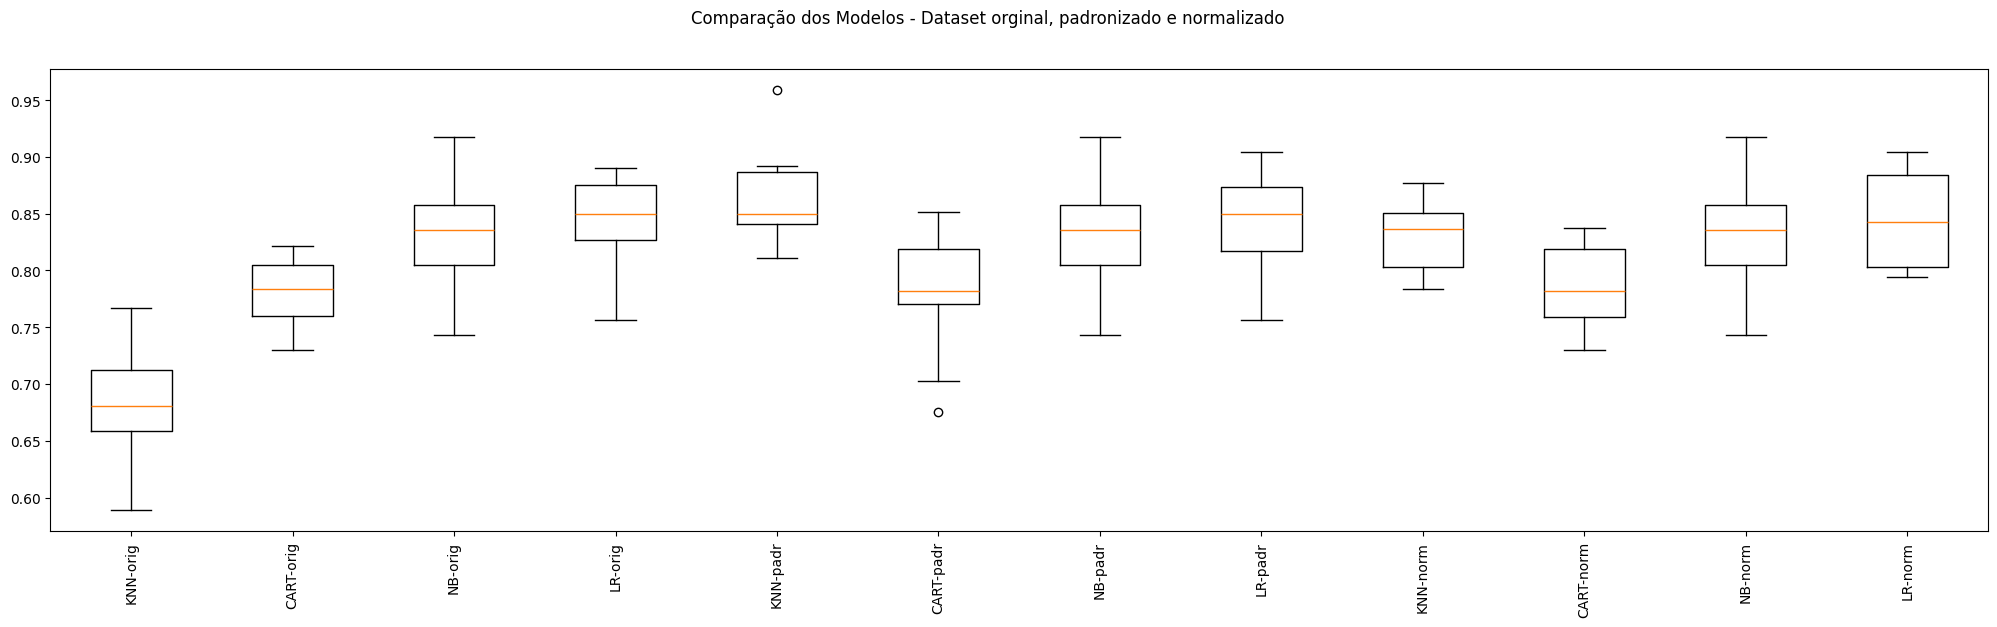

In [132]:
np.random.seed(7) # definindo uma semente global para este bloco

# Listas para armazenar os pipelines e os resultados para todas as visões do dataset
pipelines = []
results = []
names = []

# Criando os elementos do pipeline

# Algoritmos que serão utilizados
knn = ('KNN', KNeighborsClassifier())
cart = ('CART', DecisionTreeClassifier())
naive_bayes = ('NB', GaussianNB())
logistic_regression = ('LR', LogisticRegression())

# Transformações que serão utilizadas (Padronização e normalização)
standard_scaler = ('StandardScaler', StandardScaler())
min_max_scaler = ('MinMaxScaler', MinMaxScaler())

# Montando os pipelines

# Dataset original
pipelines.append(('KNN-orig', Pipeline([knn])))
pipelines.append(('CART-orig', Pipeline([cart])))
pipelines.append(('NB-orig', Pipeline([naive_bayes])))
pipelines.append(('LR-orig', Pipeline([logistic_regression])))

# Dataset Padronizado
pipelines.append(('KNN-padr', Pipeline([standard_scaler, knn])))
pipelines.append(('CART-padr', Pipeline([standard_scaler, cart])))
pipelines.append(('NB-padr', Pipeline([standard_scaler, naive_bayes])))
pipelines.append(('LR-padr', Pipeline([standard_scaler, logistic_regression])))

# Dataset Normalizado
pipelines.append(('KNN-norm', Pipeline([min_max_scaler, knn])))
pipelines.append(('CART-norm', Pipeline([min_max_scaler, cart])))
pipelines.append(('NB-norm', Pipeline([min_max_scaler, naive_bayes])))
pipelines.append(('LR-norm', Pipeline([min_max_scaler, logistic_regression])))

# Executando os pipelines
for name, model in pipelines:
    cv_results = cross_val_score(model, X_train, y_train, cv=kfold, scoring=scoring)
    results.append(cv_results)
    names.append(name)
    msg = "%s: %.4f (%.4f)" % (name, cv_results.mean(), cv_results.std()) # formatando para 3 casas decimais
    print(msg)

# Boxplot de comparação dos modelos
fig = plt.figure(figsize=(25,6))
fig.suptitle('Comparação dos Modelos - Dataset orginal, padronizado e normalizado')
ax = fig.add_subplot(111)
plt.boxplot(results)
ax.set_xticklabels(names, rotation=90)
plt.show()

# Tunning
Após a etapa de comparação dos modelos, como os algoritmos KNN, LR e NB tiveram desempenhos próximos, decidi fazer o tunning dos três, com o intuito de avaliar se algum deles teria algum ganho significativo para servir como desempate na escolha do algoritmo.

In [133]:
# Tuning do LR - https://www.geeksforgeeks.org/machine-learning/how-to-optimize-logistic-regression-performance/

tunning_LR_pipelines = []

tunning_LR_pipelines.append(('logistic_regression-orig', Pipeline(steps=[logistic_regression])))
tunning_LR_pipelines.append(('logistic_regression-padr', Pipeline(steps=[standard_scaler, logistic_regression])))
tunning_LR_pipelines.append(('logistic_regression-norm', Pipeline(steps=[min_max_scaler, logistic_regression])))

param_grid = {
    'LR__penalty':['l1','l2','elasticnet','none'],
    'LR__C' : [0.001, 0.01, 0.1, 1, 10, 100],
    'LR__solver': ['lbfgs','newton-cg','liblinear','sag','saga'],
}

# Prepara e executa o GridSearchCV
for name, model in tunning_LR_pipelines:
    grid = GridSearchCV(estimator=model, param_grid=param_grid, scoring=scoring, cv=kfold)
    grid.fit(X_train, y_train)
    # imprime a melhor configuração
    print("Sem tratamento de missings: %s - Melhor: %f usando %s" % (name, grid.best_score_, grid.best_params_))

Sem tratamento de missings: logistic_regression-orig - Melhor: 0.844743 usando {'LR__C': 100, 'LR__penalty': 'l2', 'LR__solver': 'lbfgs'}
Sem tratamento de missings: logistic_regression-padr - Melhor: 0.848815 usando {'LR__C': 0.1, 'LR__penalty': 'l1', 'LR__solver': 'saga'}
Sem tratamento de missings: logistic_regression-norm - Melhor: 0.848815 usando {'LR__C': 0.1, 'LR__penalty': 'l1', 'LR__solver': 'liblinear'}


In [134]:
# Tuning do NB

tunning_NB_pipelines = []

tunning_NB_pipelines.append(('NB-orig', Pipeline(steps=[naive_bayes])))
tunning_NB_pipelines.append(('NB-padr', Pipeline(steps=[standard_scaler, naive_bayes])))
tunning_NB_pipelines.append(('NB-norm', Pipeline(steps=[min_max_scaler, naive_bayes])))

param_grid = {
    'NB__var_smoothing': np.logspace(0, -9, num=100)
}

# Prepara e executa o GridSearchCV
for name, model in tunning_NB_pipelines:
    grid = GridSearchCV(estimator=model, param_grid=param_grid, scoring=scoring, cv=kfold)
    grid.fit(X_train, y_train)
    # imprime a melhor configuração
    print("Sem tratamento de missings: %s - Melhor: %f usando %s" % (name, grid.best_score_, grid.best_params_))

Sem tratamento de missings: NB-orig - Melhor: 0.835246 usando {'NB__var_smoothing': np.float64(3.511191734215127e-05)}
Sem tratamento de missings: NB-padr - Melhor: 0.837986 usando {'NB__var_smoothing': np.float64(0.2848035868435802)}
Sem tratamento de missings: NB-norm - Melhor: 0.839282 usando {'NB__var_smoothing': np.float64(0.15199110829529336)}


In [135]:
# Tuning do KNN

tunning_KNN_pipelines = []

# Definindo os componentes do pipeline
standard_scaler = ('StandardScaler', StandardScaler())
min_max_scaler = ('MinMaxScaler', MinMaxScaler())

tunning_KNN_pipelines.append(('knn-orig', Pipeline(steps=[knn])))
tunning_KNN_pipelines.append(('knn-padr', Pipeline(steps=[standard_scaler, knn])))
tunning_KNN_pipelines.append(('knn-norm', Pipeline(steps=[min_max_scaler, knn])))

param_grid = {
    'KNN__n_neighbors': [1,3,5,7,9,11,13,15,17,19,21],
    'KNN__metric': ["euclidean", "manhattan", "minkowski"],
}

# Prepara e executa o GridSearchCV
for name, model in tunning_KNN_pipelines:
    grid = GridSearchCV(estimator=model, param_grid=param_grid, scoring=scoring, cv=kfold)
    grid.fit(X_train, y_train)
    # imprime a melhor configuração
    print("Sem tratamento de missings: %s - Melhor: %f usando %s" % (name, grid.best_score_, grid.best_params_))

Sem tratamento de missings: knn-orig - Melhor: 0.748019 usando {'KNN__metric': 'manhattan', 'KNN__n_neighbors': 15}
Sem tratamento de missings: knn-padr - Melhor: 0.870622 usando {'KNN__metric': 'manhattan', 'KNN__n_neighbors': 7}
Sem tratamento de missings: knn-norm - Melhor: 0.854276 usando {'KNN__metric': 'manhattan', 'KNN__n_neighbors': 21}


# Escolha do modelo final e seus hiperparâmetros
Avaliando o desempenho de acurácia e levando em consideração o tempo de execução do treinamento de cada algoritmo, o algorimo escolhido foi o KNN utilizando como parâmetros:
* metric='manhattan'
* n-neighbors=7
* dados padronizados



In [136]:
# Avaliação do modelo com o conjunto de testes

# Preparação do modelo
scaler = StandardScaler().fit(X_train) # ajuste do scaler com o conjunto de treino
rescaledX = scaler.transform(X_train) # aplicação da padronização no conjunto de treino
model = KNeighborsClassifier(metric='manhattan', n_neighbors=7)
model.fit(rescaledX, y_train)

# Estimativa da acurácia no conjunto de teste
rescaledTestX = scaler.transform(X_test) # aplicação da padronização no conjunto de teste
predictions = model.predict(rescaledTestX)
print(accuracy_score(y_test, predictions))

0.875


# Teste com novos dados

In [143]:
# Novos dados - não sabemos a classe!
data = {'Age':  [30, 42, 51],
        'Sex': [0, 0, 1],
        'ChestPainType': [0, 0, 2],
        'RestingBP' : [140, 130, 150],
        'FastingBS': [0, 1, 0],
        'RestingECG': [1, 0, 2],
        'MaxHR': [130, 137, 160],
        'ExerciseAngina': [0, 1, 0],
        'Oldpeak': [0.0, 0.0, 1.5],
        'ST_Slope': [1, 1, 0],
        }

atributos = ['Age', 'Sex', 'ChestPainType', 'RestingBP', 'FastingBS', 'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope']
entrada = pd.DataFrame(data, columns=atributos)

array_entrada = entrada.values
X_entrada = array_entrada[:,0:10].astype(float)

# Padronização nos dados de entrada usando o scaler utilizado em X
rescaledEntradaX = scaler.transform(X_entrada)

# Print dos dados para verificação
print(X_entrada)
print(rescaledEntradaX)

[[ 30.    0.    0.  140.    0.    1.  130.    0.    0.    1. ]
 [ 42.    0.    0.  130.    1.    0.  137.    1.    0.    1. ]
 [ 51.    1.    2.  150.    0.    2.  160.    0.    1.5   0. ]]
[[-2.53498959 -0.50467896 -1.71153334  0.42331206 -0.56791066  0.49936495
  -0.29698852 -0.8431819  -0.83568186  0.62007277]
 [-1.24082693 -0.50467896 -1.71153334 -0.13946833  1.76084033 -0.75588804
  -0.01684771  1.18598372 -0.83568186  0.62007277]
 [-0.27020494  1.98145767  0.65208937  0.98609245 -0.56791066  1.75461795
   0.90361498 -0.8431819   0.54313685 -1.03495782]]


In [144]:
# Predição de classes dos dados de entrada
saidas = model.predict(rescaledEntradaX)
print(saidas)

[0. 1. 0.]


# Salvamento do modelo, scaler e arquivos de teste para uso no projeto

In [139]:
# Salva o modelo no disco
filename = 'model.pkl'
dump(model, open(filename, 'wb'))

In [140]:
# Salva scaler no disco
scaler_filename = 'scaler.pkl'
dump(scaler, open(scaler_filename, 'wb'))

In [141]:
# Salva arquivos de teste em .csv no disco
np.savetxt("X_test.csv", X_test, delimiter=",")
np.savetxt("y_test.csv", y_test, delimiter=",")

In [142]:
# Testando modelo com arquivos salvos (modelo, scaler, X_test e y_test)
loaded_model = load(open(filename, 'rb'))
loaded_scaler = load(open(scaler_filename, 'rb'))
loaded_X_test = np.loadtxt("X_test.csv", delimiter=',')
loaded_y_test = np.loadtxt("y_test.csv", delimiter=',')
Rescaled_loaded_X_test = loaded_scaler.transform(loaded_X_test)
result = loaded_model.score(Rescaled_loaded_X_test, loaded_y_test)
print(result)

0.875


# Conclusão
O dataset estava bem documentado e estruturado, fazendo muita diferença no trabalho de avaliação de quais features deveriam ou não ser incluídas no treinamento do modelo.

A remoção da coluna "Cholesterol" não causou impacto significativo no resultado da acurácia e trouxe mais confiança nos resultados obtidos. A versão com a coluna "Cholesterol" havia obtido um score final de 0.88 contra 0.875 da versão sem a coluna.

A padronização e normalização dos dados em conjunto com a otimização de hiperparâmetros, para este caso de uso, só obteve influência significativa no algoritmo de KNN, tendo um grande crescimento no desempenho da acurácia. Além disso, o modelo KNN também se mostrou mais rápido que os demais durante os treinamentos


